In [1]:
from pyspark.sql import SparkSession
import seaborn as sns
import matplotlib.pyplot as plt

# Start a Spark Session
spark = SparkSession.builder \
    .appName("SmartSales") \
    .config("spark.jars", "/Users/silvertiger/Projects/smart-store-drew-schaffner/lib/sqlite-jdbc-3.49.1.0.jar") \
    .config("spark.drive.extraClassPath", "/Users/silvertiger/Projects/smart-store-drew-schaffner/lib/sqlite-jdbc-3.49.1.0.jar") \
    .getOrCreate()

# Load sale table
df_sale = spark.read.format("jdbc") \
    .option("url", "jdbc:sqlite:/Users/silvertiger/Projects/smart-store-drew-schaffner/data/dw/smart_sales.db") \
    .option("dbtable", "sale") \
    .option("driver", "org.sqlite.JDBC") \
    .load()

# Load customer table
df_customer = spark.read.format("jdbc") \
    .option("url", "jdbc:sqlite:/Users/silvertiger/Projects/smart-store-drew-schaffner/data/dw/smart_sales.db") \
    .option("dbtable", "customer") \
    .option("driver", "org.sqlite.JDBC") \
    .load()

# Load product table
df_product = spark.read.format("jdbc") \
    .option("url", "jdbc:sqlite:/Users/silvertiger/Projects/smart-store-drew-schaffner/data/dw/smart_sales.db") \
    .option("dbtable", "product") \
    .option("driver", "org.sqlite.JDBC") \
    .load()

# Un# to show the dataframes
df_customer.show()
df_sale.show()
df_product.show()


# Register DataFrames as temporary views (if not already done)
df_sale.createOrReplaceTempView("sale")
df_customer.createOrReplaceTempView("customer")
df_product.createOrReplaceTempView("product")

# print(spark.catalog.listTables())

# Write query using Spark SQL
df_top_customers = spark.sql("""
SELECT c.name, SUM(s.sale_amount) AS total_spent
FROM sale s
JOIN customer c ON s.customer_id = c.customer_id
GROUP BY c.name
ORDER BY total_spent DESC
""")

df_sales_trends = spark.sql("""
SELECT
    DATE_TRUNC('month', to_timestamp(s.sale_date, 'M/d/yy')) AS sale_month,
    SUM(s.sale_amount) AS monthly_sales,
    p.category AS product_category
FROM
    sale s
JOIN
    product p ON s.product_id = p.product_id
GROUP BY
    sale_month, p.category
ORDER BY
    sale_month
""")

# Show spark results
# df_top_customers.show()
df_sales_trends.show()

# Convert to Pandas DataFrame for visualization
df_top_customers_pd = df_top_customers.toPandas()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
{"ts":"2025-04-18T23:36:09.422Z","level":"WARN","msg":"Your hostname, Drews-MacBook-Pro-2.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.140 instead (on interface en0)","context":{"host":"Drews-MacBook-Pro-2.local","host_port":"127.0.0.1","host_port2":"192.168.0.140","network_if":"en0"},"logger":"Utils"}
{"ts":"2025-04-18T23:36:09.424Z","level":"WARN","msg":"Set SPARK_LOCAL_IP if you need to bind to another address","logger":"Utils"}
{"ts":"2025-04-18T23:36:09.650Z","level":"WARN","msg":"Unable to load native-hadoop library for your platform... using builtin-java classes where applicable","logger":"NativeCodeLoader"}
{"ts":"2025-04-18T23:36:09.827Z","level":"INFO","msg":"Running Spark version 4.0.0-preview1","logger":"SparkContext"}
{"ts":"2025-04-18T23:36:09.828Z","level":"INFO","msg":"OS info Mac OS X, 15.4, aarch64","logger":"SparkContext"}
{"ts":"2025-04-18T23:36:09.829Z","level":"IN

+-----------+----------------+------+---------+----------------+------------------+------------------------+
|customer_id|            name|region|join_date|last_active_year|             email|preferred_contact_method|
+-----------+----------------+------+---------+----------------+------------------+------------------------+
|       1001|   William White|  East| 11/11/21|            2022| william@gmail.com|                   email|
|       1002|    Wylie Coyote|  East|  2/14/23|            2025|   wylie@gmail.com|                   phone|
|       1003|       Dan Brown|  West| 10/19/23|            2020|     dan@gmail.com|                   phone|
|       1004|       Chewbacca|  West|  11/9/22|            2021|   chewy@gmail.com|                   email|
|       1005|          Dr Who| North|  8/18/23|            2024|   drwho@gmail.com|                   phone|
|       1006|   Tiffany James| South|   6/7/21|            2022|  tiff@outlook.com|                   email|
|       1007|   Sus

{"ts":"2025-04-18T23:36:13.778Z","level":"INFO","msg":"Finished task 0.0 in stage 2.0 (TID 2). 2176 bytes result sent to driver","context":{"task_name":"task 0.0 in stage 2.0 (TID 2)"},"logger":"Executor"}
{"ts":"2025-04-18T23:36:13.779Z","level":"INFO","msg":"Finished task 0.0 in stage 2.0 (TID 2) in 19 ms on 192.168.0.140 (executor driver) (1/1)","logger":"TaskSetManager"}
{"ts":"2025-04-18T23:36:13.779Z","level":"INFO","msg":"Removed TaskSet 2.0, whose tasks have all completed, from pool ","logger":"TaskSchedulerImpl"}
{"ts":"2025-04-18T23:36:13.780Z","level":"INFO","msg":"ResultStage 2 (showString at NativeMethodAccessorImpl.java:0) finished in 33 ms","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:13.780Z","level":"INFO","msg":"Job 2 is finished. Cancelling potential speculative or zombie tasks for this job","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:13.780Z","level":"INFO","msg":"Canceling stage 2","logger":"TaskSchedulerImpl"}
{"ts":"2025-04-18T23:36:13.780Z","level":"INF

+----------+------------+-----------+----------+--------------+----------+
|product_id|product_name|   category|unit_price|stock_quantity|  supplier|
+----------+------------+-----------+----------+--------------+----------+
|       101|      laptop|Electronics|    793.12|           432|        HP|
|       102|      hoodie|   Clothing|      39.1|           523|      Nike|
|       103|       cable|Electronics|     22.76|            62|RocketFish|
|       104|         hat|   Clothing|      43.1|           792|      Nike|
|       105|    football|     Sports|     19.78|           555|  Spalding|
|       106|  controller|Electronics|     88.98|           672|      Xbox|
|       107|      jacket|   Clothing|     67.02|           354|      Nike|
|       108|   protector|Electronics|     12.56|           457|     Apple|
+----------+------------+-----------+----------+--------------+----------+



{"ts":"2025-04-18T23:36:14.106Z","level":"INFO","msg":"Code generated in 5.819833 ms","logger":"CodeGenerator"}
{"ts":"2025-04-18T23:36:14.117Z","level":"INFO","msg":"Registering RDD 12 (showString at NativeMethodAccessorImpl.java:0) as input to shuffle 0","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:14.121Z","level":"INFO","msg":"Got map stage job 3 (showString at NativeMethodAccessorImpl.java:0) with 1 output partitions","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:14.122Z","level":"INFO","msg":"Final stage: ShuffleMapStage 3 (showString at NativeMethodAccessorImpl.java:0)","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:14.122Z","level":"INFO","msg":"Parents of final stage: List()","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:14.123Z","level":"INFO","msg":"Missing parents: List()","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:14.123Z","level":"INFO","msg":"Submitting ShuffleMapStage 3 (MapPartitionsRDD[12] at showString at NativeMethodAccessorImpl.java:0), which has 

+-------------------+------------------+----------------+
|         sale_month|     monthly_sales|product_category|
+-------------------+------------------+----------------+
|2024-01-01 00:00:00|             19.78|          Sports|
|2024-01-01 00:00:00|           5551.84|     Electronics|
|2024-01-01 00:00:00|             859.4|        Clothing|
|2024-02-01 00:00:00|2323.3999999999996|        Clothing|
|2024-02-01 00:00:00|12129.599999999999|     Electronics|
|2024-02-01 00:00:00|            138.46|          Sports|
|2024-03-01 00:00:00|            178.02|          Sports|
|2024-03-01 00:00:00|          11972.16|     Electronics|
|2024-04-01 00:00:00|             778.9|        Clothing|
|2024-04-01 00:00:00|             39.56|          Sports|
|2024-04-01 00:00:00|16126.640000000001|     Electronics|
|2024-05-01 00:00:00|              98.9|          Sports|
|2024-05-01 00:00:00|           8749.44|     Electronics|
|2024-05-01 00:00:00|           2134.48|        Clothing|
|2024-06-01 00

{"ts":"2025-04-18T23:36:14.827Z","level":"INFO","msg":"Removed broadcast_5_piece0 on 192.168.0.140:58738 in memory (size: 25.3 KiB, free: 434.4 MiB)","logger":"BlockManagerInfo"}
{"ts":"2025-04-18T23:36:14.838Z","level":"INFO","msg":"Code generated in 26.318 ms","logger":"CodeGenerator"}
{"ts":"2025-04-18T23:36:14.852Z","level":"INFO","msg":"Registering RDD 38 (toPandas at /var/folders/32/rlhj6fw174d26m4swqhj7fq80000gn/T/ipykernel_2247/2449763750.py:75) as input to shuffle 5","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:14.852Z","level":"INFO","msg":"Got map stage job 9 (toPandas at /var/folders/32/rlhj6fw174d26m4swqhj7fq80000gn/T/ipykernel_2247/2449763750.py:75) with 1 output partitions","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:14.852Z","level":"INFO","msg":"Final stage: ShuffleMapStage 16 (toPandas at /var/folders/32/rlhj6fw174d26m4swqhj7fq80000gn/T/ipykernel_2247/2449763750.py:75)","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:14.852Z","level":"INFO","msg":"Parents of

{"ts":"2025-04-18T23:36:15.203Z","level":"INFO","msg":"Code generated in 8.59325 ms","logger":"CodeGenerator"}
{"ts":"2025-04-18T23:36:15.206Z","level":"INFO","msg":"Registering RDD 50 (showString at NativeMethodAccessorImpl.java:0) as input to shuffle 7","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:15.206Z","level":"INFO","msg":"Got map stage job 13 (showString at NativeMethodAccessorImpl.java:0) with 1 output partitions","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:15.206Z","level":"INFO","msg":"Final stage: ShuffleMapStage 30 (showString at NativeMethodAccessorImpl.java:0)","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:15.206Z","level":"INFO","msg":"Parents of final stage: List()","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:15.206Z","level":"INFO","msg":"Missing parents: List()","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:15.206Z","level":"INFO","msg":"Submitting ShuffleMapStage 30 (MapPartitionsRDD[50] at showString at NativeMethodAccessorImpl.java:0), which ha

+----------+------------------+
|product_id|  sum(sale_amount)|
+----------+------------------+
|       108|            992.24|
|       101|          88829.44|
|       103|             455.2|
|       107| 7305.179999999999|
|       102|2111.3999999999996|
|       105|            672.52|
|       106|           4182.06|
|       104|4008.2999999999997|
+----------+------------------+

+-----------+------------------+
|campaign_id|  sum(sale_amount)|
+-----------+------------------+
|          1|10453.820000000002|
|          3| 9492.800000000001|
|          2|           8562.78|
|          0| 80046.94000000002|
+-----------+------------------+



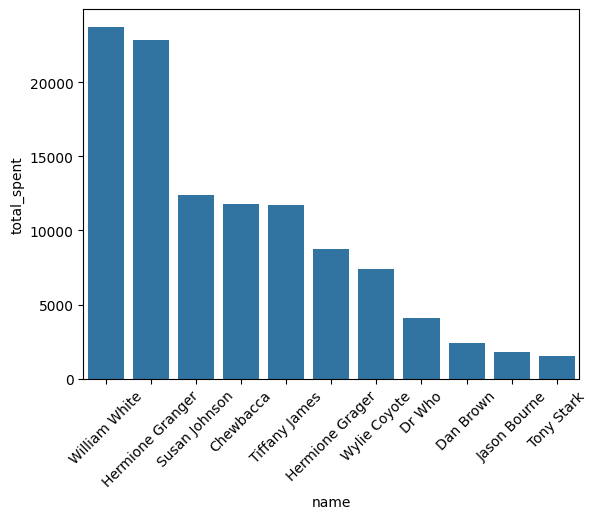

{"ts":"2025-04-18T23:36:15.496Z","level":"INFO","msg":"Removed broadcast_16_piece0 on 192.168.0.140:58738 in memory (size: 16.5 KiB, free: 434.4 MiB)","logger":"BlockManagerInfo"}
{"ts":"2025-04-18T23:36:15.498Z","level":"INFO","msg":"Removed broadcast_14_piece0 on 192.168.0.140:58738 in memory (size: 16.5 KiB, free: 434.4 MiB)","logger":"BlockManagerInfo"}
{"ts":"2025-04-18T23:36:15.503Z","level":"INFO","msg":"Removed broadcast_15_piece0 on 192.168.0.140:58738 in memory (size: 14.3 KiB, free: 434.4 MiB)","logger":"BlockManagerInfo"}
{"ts":"2025-04-18T23:36:15.512Z","level":"INFO","msg":"Registering RDD 63 (toPandas at /var/folders/32/rlhj6fw174d26m4swqhj7fq80000gn/T/ipykernel_2247/3890608280.py:12) as input to shuffle 9","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:36:15.512Z","level":"INFO","msg":"Got map stage job 17 (toPandas at /var/folders/32/rlhj6fw174d26m4swqhj7fq80000gn/T/ipykernel_2247/3890608280.py:12) with 1 output partitions","logger":"DAGScheduler"}
{"ts":"2025-04-18T23:

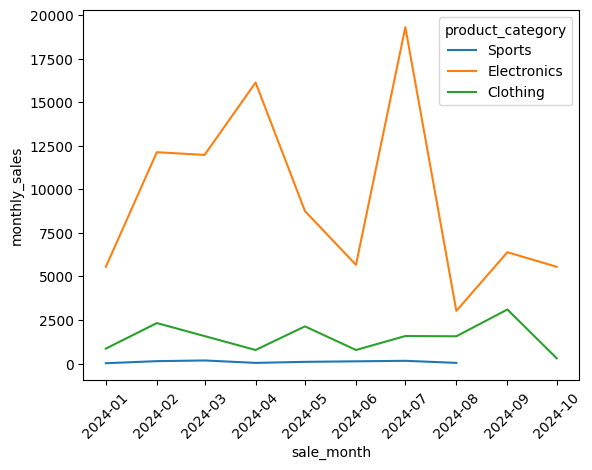

{"ts":"2025-04-19T00:12:04.829Z","level":"INFO","msg":"Removed broadcast_21_piece0 on 192.168.0.140:58738 in memory (size: 22.8 KiB, free: 434.4 MiB)","logger":"BlockManagerInfo"}
{"ts":"2025-04-19T00:12:04.830Z","level":"INFO","msg":"Removed broadcast_22_piece0 on 192.168.0.140:58738 in memory (size: 20.9 KiB, free: 434.4 MiB)","logger":"BlockManagerInfo"}


In [2]:
# This code does nothing for me but hypothetically, if my data contained a sale date that took place prior to 2023-01-01, I could filter it out. 
df_filtered = df_sale.filter(df_sale.sale_date >= "2023-01-01")

df_sale.groupby("product_id").sum("sale_amount").show()

df_sale.groupby("campaign_id").sum("sale_amount").show()

sns.barplot(data=df_top_customers_pd, x="name", y="total_spent")
plt.xticks(rotation=45)
plt.show()

sns.lineplot(data = df_sales_trends.toPandas(), x="sale_month", y="monthly_sales", hue="product_category")
plt.xticks(rotation=45)
plt.show()
